# Model Evaluation

This notebook loads the trained model from `artifact/model.pkl` and evaluates it on the held-out test set.

The model was trained on an H100 GPU via Modal (`train_model.py`) using:
1. GridSearchCV across 5 models (RF, GBM, XGBoost, LightGBM, CatBoost)
2. Stacking ensemble from the top 3 models
3. Threshold tuning (maximize accuracy with denied recall >= 60%)

**Selected model**: ThresholdClassifier(GradientBoostingClassifier, threshold=0.37)

## Setup

In [8]:
import os
import sys
import types
import pickle
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import warnings
warnings.filterwarnings("ignore")

# Pickle needs ThresholdClassifier to exist in the module before loading
import visa_approval_prediction.entity.estimator as _est

class ThresholdClassifier:
    def __init__(self, base_model, threshold=0.5):
        self.base_model = base_model
        self.threshold = threshold
    def predict(self, X):
        proba = self.base_model.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)
    def predict_proba(self, X):
        return self.base_model.predict_proba(X)

_est.ThresholdClassifier = ThresholdClassifier

os.makedirs("../figures", exist_ok=True)

## 1. Load Saved Model

In [9]:
with open("../artifact/model.pkl", "rb") as f:
    model = pickle.load(f)

# The old installed visaModel may lack predict_proba — add it if missing
if not hasattr(model, "predict_proba"):
    def _predict_proba(self, dataframe):
        transformed = self.preprocessing_object.transform(dataframe)
        return self.trained_model_object.predict_proba(transformed)
    type(model).predict_proba = _predict_proba

print(f"Loaded model: {model}")
print(f"Classifier: {model.trained_model_object}")
print(f"Preprocessor: {type(model.preprocessing_object).__name__}")

Loaded model: ThresholdClassifier()
Classifier: <__main__.ThresholdClassifier object at 0x000002B7724E4D70>
Preprocessor: ColumnTransformer


## 2. Reproduce Test Split

Using the same feature engineering and `train_test_split(random_state=42, stratify=y)` as training to get the identical test set.

In [10]:
df = pd.read_csv("../EasyVisa.csv")

# Feature engineering (same as train_model.py)
current_year = date.today().year
df["company_age"] = current_year - df["yr_of_estab"]
df.drop(columns=["case_id", "yr_of_estab"], inplace=True)

# Encode target
df["case_status"] = df["case_status"].map({"Certified": 0, "Denied": 1})

X = df.drop(columns=["case_status"])
y = df["case_status"]

# Same split as training
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Test set: {X_test.shape[0]} samples")
print(f"  Certified: {(y_test == 0).sum()}, Denied: {(y_test == 1).sum()}")

Test set: 5096 samples
  Certified: 3404, Denied: 1692


## 3. Generate Predictions

In [11]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
denied_recall = recall_score(y_test, y_pred, pos_label=1)

print(f"Accuracy:       {acc:.4f}")
print(f"F1 Score:       {f1:.4f}")
print(f"Precision:      {prec:.4f}")
print(f"Denied Recall:  {denied_recall:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Certified", "Denied"]))

Accuracy:       0.7323
F1 Score:       0.6035
Precision:      0.5938
Denied Recall:  0.6135

              precision    recall  f1-score   support

   Certified       0.80      0.79      0.80      3404
      Denied       0.59      0.61      0.60      1692

    accuracy                           0.73      5096
   macro avg       0.70      0.70      0.70      5096
weighted avg       0.73      0.73      0.73      5096



## 4. Confusion Matrix (Figure 7)

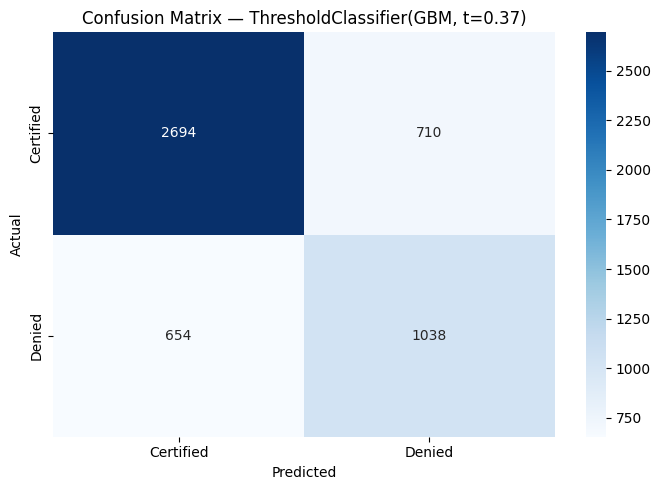


TN=2694, FP=710, FN=654, TP=1038


In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Certified", "Denied"],
    yticklabels=["Certified", "Denied"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — ThresholdClassifier(GBM, t=0.37)")
plt.tight_layout()
plt.savefig("../figures/fig7_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")

## 5. Threshold Tuning Curve (Figure 8)

The model's base GradientBoostingClassifier outputs probabilities. The optimal threshold (0.37) was chosen to maximize accuracy while keeping denied recall >= 60%.

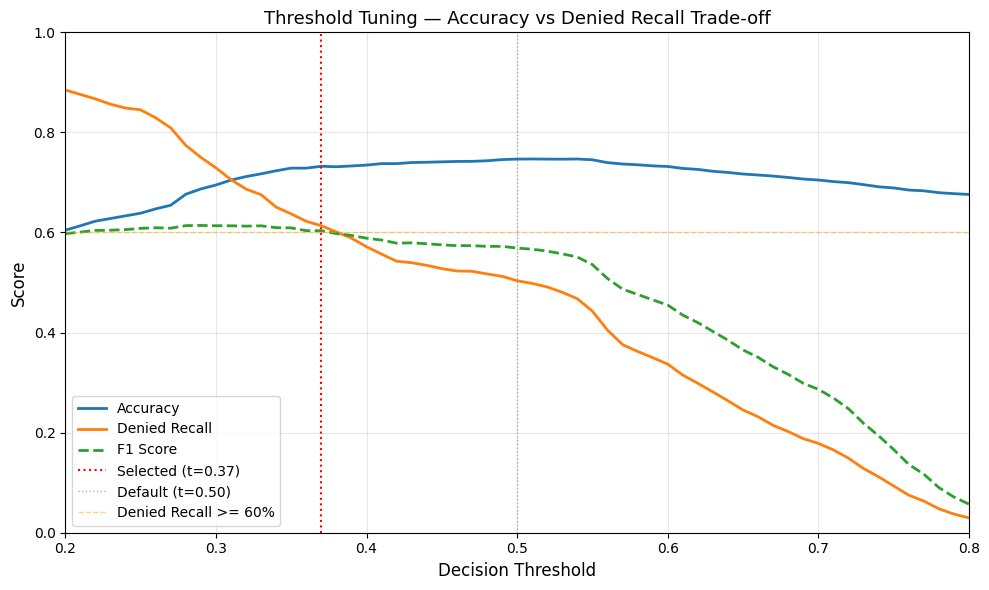

In [13]:
thresholds = np.arange(0.20, 0.81, 0.01)
accuracies = []
denied_recalls = []
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    accuracies.append(accuracy_score(y_test, y_pred_t))
    denied_recalls.append(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, accuracies, label="Accuracy", linewidth=2)
ax.plot(thresholds, denied_recalls, label="Denied Recall", linewidth=2)
ax.plot(thresholds, f1_scores, label="F1 Score", linewidth=2, linestyle="--")

# Mark the selected threshold
ax.axvline(x=0.37, color="red", linestyle=":", linewidth=1.5, label="Selected (t=0.37)")
# Mark the default threshold
ax.axvline(x=0.50, color="gray", linestyle=":", linewidth=1, alpha=0.6, label="Default (t=0.50)")

# Mark the denied recall constraint
ax.axhline(y=0.60, color="orange", linestyle="--", linewidth=1, alpha=0.5, label="Denied Recall >= 60%")

ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Threshold Tuning — Accuracy vs Denied Recall Trade-off", fontsize=13)
ax.legend(loc="lower left", fontsize=10)
ax.set_xlim(0.20, 0.80)
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/fig8_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Model Comparison (Figure 9)

Results from `modal run train_model.py` — all models trained on the same train/test split with GridSearchCV (5-fold CV, accuracy scoring).

In [14]:
# Results from Modal training run
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Stacking (top 3)",
        "GBM + Threshold (0.37)",
    ],
    "Accuracy": [0.738, 0.747, 0.746, 0.731, 0.722, 0.746, 0.732],
    "F1": [0.550, 0.569, 0.567, 0.592, 0.595, 0.572, 0.604],
    "Denied Recall": [0.481, 0.504, 0.502, 0.587, 0.615, 0.513, 0.614],
})

print(comparison.to_string(index=False))

                 Model  Accuracy    F1  Denied Recall
         Random Forest     0.738 0.550          0.481
     Gradient Boosting     0.747 0.569          0.504
               XGBoost     0.746 0.567          0.502
              LightGBM     0.731 0.592          0.587
              CatBoost     0.722 0.595          0.615
      Stacking (top 3)     0.746 0.572          0.513
GBM + Threshold (0.37)     0.732 0.604          0.614


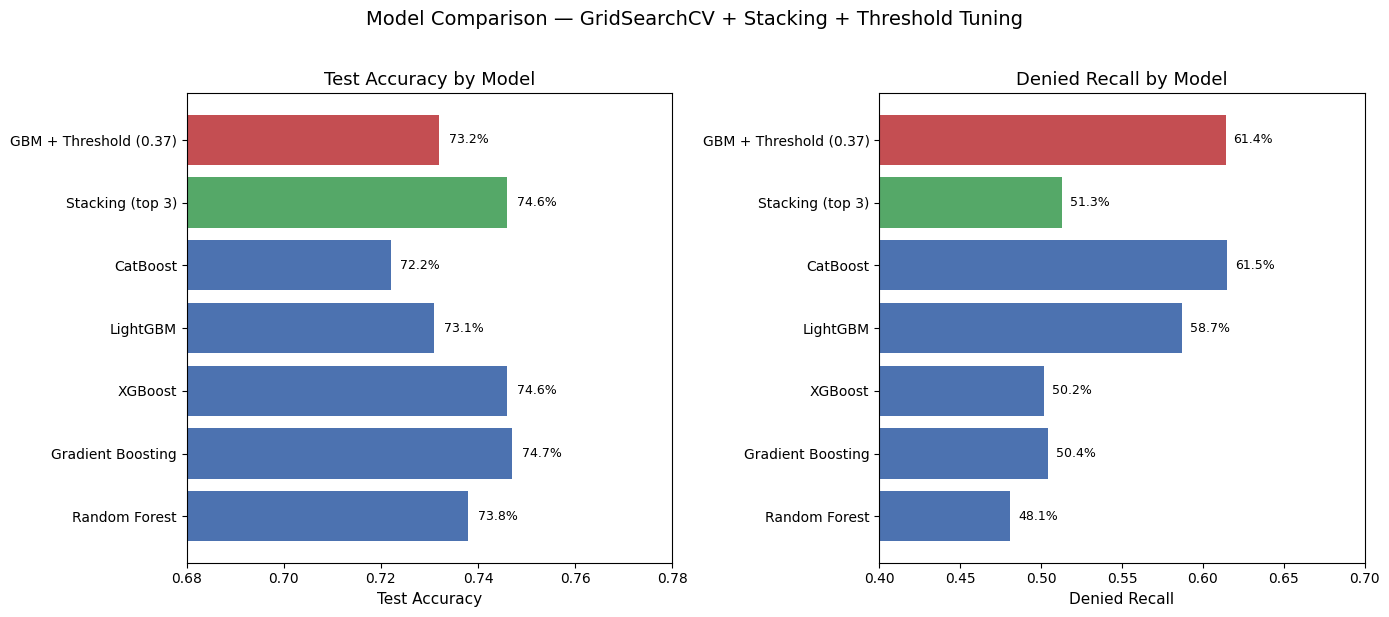

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#4C72B0"] * 5 + ["#55A868", "#C44E52"]

# Accuracy
bars1 = axes[0].barh(comparison["Model"], comparison["Accuracy"], color=colors)
axes[0].set_xlabel("Test Accuracy", fontsize=11)
axes[0].set_title("Test Accuracy by Model", fontsize=13)
axes[0].set_xlim(0.68, 0.78)
for bar, val in zip(bars1, comparison["Accuracy"]):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1%}", va="center", fontsize=9)

# Denied Recall
bars2 = axes[1].barh(comparison["Model"], comparison["Denied Recall"], color=colors)
axes[1].set_xlabel("Denied Recall", fontsize=11)
axes[1].set_title("Denied Recall by Model", fontsize=13)
axes[1].set_xlim(0.40, 0.70)
for bar, val in zip(bars2, comparison["Denied Recall"]):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1%}", va="center", fontsize=9)

plt.suptitle("Model Comparison — GridSearchCV + Stacking + Threshold Tuning", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/fig9_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Key Takeaways

1. **Gradient Boosting** had the highest individual accuracy (74.7%) but only 50.4% denied recall at the default 0.5 threshold.
2. **CatBoost** achieved the best native denied recall (61.5%) due to its built-in class weighting, but at lower accuracy (72.2%).
3. **Stacking** did not improve over the best individual model — the top 3 models (RF, GBM, XGB) are too architecturally similar to provide diversity gains.
4. **Threshold tuning** on Gradient Boosting (lowering threshold from 0.50 to 0.37) traded 1.5% accuracy for +11% denied recall — the best balance for an advisory tool.

**Final model**: `ThresholdClassifier(GradientBoostingClassifier, threshold=0.37)` — **73.2% accuracy**, **61.4% denied recall**.